# Week 4 - #06 Attention Model



# Assignment

Implement an attention mechanism for text summarization and report the results.

Dataset: [VNDS - A Vietnamese Dataset for Summarization](https://huggingface.co/datasets/nam194/vietnews/tree/main)

In [1]:
from datasets import load_dataset, DatasetDict
import pandas as pd
import numpy as np
import re
import random
import time
import os
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [2]:
dataset = load_dataset('nam194/vietnews')

README.md:   0%|          | 0.00/748 [00:00<?, ?B/s]

data/train-00000-of-00001-84acb79f6c6547(…):   0%|          | 0.00/170M [00:00<?, ?B/s]

data/validation-00000-of-00001-210cc51bf(…):   0%|          | 0.00/38.3M [00:00<?, ?B/s]

data/test-00000-of-00001-123f98d55067eb7(…):   0%|          | 0.00/38.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/99134 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/22184 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22498 [00:00<?, ? examples/s]

In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['guid', 'title', 'abstract', 'article'],
        num_rows: 99134
    })
    validation: Dataset({
        features: ['guid', 'title', 'abstract', 'article'],
        num_rows: 22184
    })
    test: Dataset({
        features: ['guid', 'title', 'abstract', 'article'],
        num_rows: 22498
    })
})


In [4]:
dataset['train'][0]

{'guid': 1,
 'title': 'Khởi_tố kẻ_trộm hơn 1 tạ thóc và hơn 8 triệu đồng của chú ruột để lấy tiền mua ma_tuý',
 'abstract': 'Với bản_tính ham chơi , lười làm , có nhiều tiền_án tiền_sự , lại nghiện ma_tuý , Thương đã đột_nhập vào nhà chú ruột để trộm hơn 1 tạ thóc và hơn 8 triệu đồng mang đi tiêu_xài .',
 'article': 'Ngày 27/3 , Cơ_quan Cảnh_sát điều_tra Công_an TP. Hưng_Yên , tỉnh Hưng_Yên cho biết , đơn_vị vừa ra quyết_định khởi_tố vụ án , khởi_tố bị_can đối_với đối_tượng Mai_Văn_Thương ( SN 1989 , trú tại đội 11 , thôn An_Chiểu 1 , xã Liên_Phương , TP. Hưng_Yên ) để điều_tra về hành_vi trộm_cắp tài_sản . Theo tài_liệu điều_tra của cơ_quan công_an , vào_khoảng 7h30 ngày 13/3 , lợi_dụng gia_đình ông Mai_Văn_Thịnh ( chú ruột đối_tượng Thương ) ở cạnh nhà đi vắng , đối_tượng này đã đạp gãy chấn_song cửa_sổ , đột_nhập vào nhà ông Thịnh trộm_cắp 121kg thóc mang bán cho người cùng thôn lấy 700.000 đ . Không dừng lại , sau đó đối_tượng tiếp_tục quay lại lục_soát tủ nhà ông Thịnh trộm_cắp 8.

In [5]:
dataset = dataset.remove_columns(["guid", "title"])
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['abstract', 'article'],
        num_rows: 99134
    })
    validation: Dataset({
        features: ['abstract', 'article'],
        num_rows: 22184
    })
    test: Dataset({
        features: ['abstract', 'article'],
        num_rows: 22498
    })
})


In [6]:
trainset = dataset['train']
valset = dataset['validation']
testset = dataset['test']

def eda(dataset):
    input_lens, output_lens = [], []
    for sample in dataset:
        input_len = len(sample['article'].split())
        output_len = len(sample['abstract'].split())
        input_lens.append(input_len)
        output_lens.append(output_len)
    print(f"Input length - Total: {sum(input_lens)}, Average: {(sum(input_lens)/len(input_lens)):.1f}, Max: {max(input_lens)}.")
    print(f"Output length - Total: {sum(output_lens)}, Average: {(sum(output_lens)/len(output_lens)):.1f}, Max: {max(output_lens)}.")
    print()

print("Train set:")
eda(trainset)
print("Validation set:")
eda(valset)
print("Test set:")
eda(testset)

Train set:
Input length - Total: 41115399, Average: 414.7, Max: 2121.
Output length - Total: 2798674, Average: 28.2, Max: 123.

Validation set:
Input length - Total: 9287387, Average: 418.7, Max: 1875.
Output length - Total: 631607, Average: 28.5, Max: 108.

Test set:
Input length - Total: 9413316, Average: 418.4, Max: 1683.
Output length - Total: 642663, Average: 28.6, Max: 97.



## Preprocess Dataset

In [7]:
examples = DatasetDict({split: ds.select(range(10)) if split != 'train' else ds.select(range(100)) for split, ds in dataset.items()})
print(examples)

DatasetDict({
    train: Dataset({
        features: ['abstract', 'article'],
        num_rows: 100
    })
    validation: Dataset({
        features: ['abstract', 'article'],
        num_rows: 10
    })
    test: Dataset({
        features: ['abstract', 'article'],
        num_rows: 10
    })
})


In [8]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

MAX_INPUT_LEN = 256
MAX_TARGET_LEN = 30

def preprocess(examples):
    # Encoder input: article
    model_inputs = tokenizer(
        examples['article'],
        max_length=MAX_INPUT_LEN,
        padding='max_length',
        truncation=True
    )

    # Decoder target: abstract
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            examples['abstract'],
            max_length=MAX_TARGET_LEN,
            padding='max_length',
            truncation=True
        )

    # Add labels
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Using `PhoBERT` for auto add `<sos>`, `<eos>`, `<pad>` tokens, good for vietnamese.

In [9]:
encoded_examples = examples.map(preprocess, batched=True)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3959: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

In [10]:
print(encoded_examples['train'][0])

{'abstract': 'Với bản_tính ham chơi , lười làm , có nhiều tiền_án tiền_sự , lại nghiện ma_tuý , Thương đã đột_nhập vào nhà chú ruột để trộm hơn 1 tạ thóc và hơn 8 triệu đồng mang đi tiêu_xài .', 'article': 'Ngày 27/3 , Cơ_quan Cảnh_sát điều_tra Công_an TP. Hưng_Yên , tỉnh Hưng_Yên cho biết , đơn_vị vừa ra quyết_định khởi_tố vụ án , khởi_tố bị_can đối_với đối_tượng Mai_Văn_Thương ( SN 1989 , trú tại đội 11 , thôn An_Chiểu 1 , xã Liên_Phương , TP. Hưng_Yên ) để điều_tra về hành_vi trộm_cắp tài_sản . Theo tài_liệu điều_tra của cơ_quan công_an , vào_khoảng 7h30 ngày 13/3 , lợi_dụng gia_đình ông Mai_Văn_Thịnh ( chú ruột đối_tượng Thương ) ở cạnh nhà đi vắng , đối_tượng này đã đạp gãy chấn_song cửa_sổ , đột_nhập vào nhà ông Thịnh trộm_cắp 121kg thóc mang bán cho người cùng thôn lấy 700.000 đ . Không dừng lại , sau đó đối_tượng tiếp_tục quay lại lục_soát tủ nhà ông Thịnh trộm_cắp 8.500.000 đ tiền_mặt ( ông Thịnh để dưới đáy tủ ) , rồi dùng số tiền trên để đi mua ma_tuý về sử_dụng và tiêu_xài 

In [11]:
# format type for PyTorch DataLoader
encoded_examples.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [12]:
encoded_examples['train'][0]

{'input_ids': tensor([    0,   319, 18828,     4,  1313,  1154,   377,   367,   334,  4092,
             4,    98,  4092,    13,    55,     4,   304,   164,    40,   261,
          2206,   178,   565,     4,  2206,  3222,   190,   429, 16929,  3999,
            20,  1258,  5045,     4,  1354,    35,   226,   624,     4,  1103,
          3187, 16748,    99,     4,   176, 50549,     4,   334,  4092,    19,
            24,   377,    28,   589,  4171,   540,     5,    79,  1715,   377,
             7,   271,   863,     4,  2188, 23949,    43, 20877,     4,  2843,
           161,    46, 16929,  3600,    20,  1393,  2075,   429,  3999,    19,
            25,   362,    69,    57,  3543,     4,   429,    23,    14,  4463,
          3439, 56599,  1180,  4185,     4,  6437,    33,    69,    46,  3600,
          4171,  2789, 12459, 11603,   156,   170,    13,    18,    81,  1103,
           273, 11741,  3494,     5,   453,   772,    44,     4,    53,    37,
           429,   194,   588,    44, 22

In [13]:
encoded_examples['train'][1]

{'input_ids': tensor([    0,  2514,  2336,   111,   200,     4,   137, 16911,    43, 16554,
             4,   154,   200,   441,     7,   180,    28,    49,    10,    82,
           276,    18,    52,  2737,   196,     6,   480,   138,    34,  3414,
          4225,     4,   367,   149, 39553,  1070, 22532,   908,    14,   767,
           945,    35,  1348,  2388,     5,   382,    97,     4,   340,   741,
           918,   300,   925,   955,     4,   445,  2037,   385,  3056,     4,
          3158, 21520,  1329,  4205,     4,  1120,   645, 35871,     4,   317,
          5944,    81,    16,   747,    45,  1736,  1149,  2685,     5,   815,
            55,     4,   398, 18117,     4,   205,   276,    10,   124,   431,
            18,   206,     5,  2891,   340,   863,   395,    25,  1348,     4,
           172,   955,    14,   485,   444,   156,  8774,   338,  1885,     5,
          1434,    34,   441,  5574,   334,   383,     4,   730,     7,   196,
         18117,     8,    91,   276,   

In [14]:
# # Apply preprocess function for Dataset
# encoded_dataset = dataset.map(preprocess, batched=True)

In [15]:
# encoded_dataset.save_to_disk('/kaggle/working/processed_vnds')

In [16]:
# # format type for PyTorch DataLoader
# encoded_dataset.set_format(
#     type="torch",
#     columns=["input_ids", "attention_mask", "labels"]
# )

In [17]:
# tokenizer.vocab_size

### Prepare DataLoader

In [18]:
# BATCH_SIZE = 8

# train_loader = DataLoader(encoded_dataset["train"], batch_size=BATCH_SIZE, shuffle=True)
# val_loader   = DataLoader(encoded_dataset["validation"], batch_size=BATCH_SIZE)
# test_loader  = DataLoader(encoded_dataset["test"], batch_size=BATCH_SIZE)

In [19]:
# batch = next(iter(train_loader))
# print(batch.keys())
# print(batch["input_ids"].shape)

In [20]:
from torch.utils.data import DataLoader, Dataset

BATCH_SIZE = 8

train_loader = DataLoader(encoded_examples["train"], batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(encoded_examples["validation"], batch_size=BATCH_SIZE)
test_loader  = DataLoader(encoded_examples["test"], batch_size=BATCH_SIZE)

In [21]:
batch = next(iter(train_loader))
print(batch.keys())
print(batch["input_ids"].shape)

dict_keys(['input_ids', 'attention_mask', 'labels'])
torch.Size([8, 256])


## Implement from scratch: Seq2Seq GRU-based with Attention

### Encoder

In [22]:
class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, pad_token_id, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_token_id)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input_ids, attention_mask):
        embedded = self.dropout(self.embedding(input_ids))
        input_length = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(embedded, input_length, enforce_sorted=False, batch_first=True)
        outputs, hidden = self.gru(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        return outputs, hidden

### Attention Layer

In [23]:
class LuongAttention(nn.Module):
    def __init__(self, hidden_size):
        super(LuongAttention, self).__init__()
        self.attn = nn.Linear(hidden_size, hidden_size)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, hidden, encoder_outputs, mask=None):
        hidden = hidden[-1].unsqueeze(2)
        scores = torch.bmm(encoder_outputs, hidden).squeeze(2)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = self.softmax(scores)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        context = context.squeeze(1) 
        return context, attn_weights


### Decoder with Attention

In [24]:
class AttnDecoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, pad_token_id, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=pad_token_id)
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(embed_size + hidden_size, hidden_size, batch_first=True)
        self.attention = LuongAttention(hidden_size)
        self.out = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, input_step, last_hidden, encoder_outputs, mask=None):
        embedded = self.dropout(self.embedding(input_step))
        embedded = embedded.unsqueeze(1)
        context, attn_weights = self.attention(last_hidden, encoder_outputs, mask)
        context = context.unsqueeze(1)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.gru(rnn_input, last_hidden)
        output = output.squeeze(1)
        context = context.squeeze(1)
        output = torch.cat((output, context), dim=1)
        logits = self.out(output)
        return logits, hidden, attn_weights


### Training

In [25]:
def train_epoch(encoder, decoder, dataloader, optimizer, criterion, pad_token_id, device, teacher_forcing_ratio=0.5, clip=1.0):
    encoder.train()
    decoder.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    
    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device) 
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["labels"].to(device)    
        optimizer.zero_grad()

        # (1) Encoder
        encoder_outputs, encoder_hidden = encoder(input_ids, attention_mask)

        # (2) Decoder init
        batch_size, tgt_len = targets.size()
        decoder_input = targets[:, 0]  # <sos> token
        decoder_hidden = encoder_hidden

        loss = 0.0

        for t in range(1, tgt_len):
            logits, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs, mask=attention_mask)
            step_loss = criterion(logits, targets[:, t])
            loss += step_loss

            # Teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio
            decoder_input = targets[:, t] if teacher_force else logits.argmax(1)

            # Debug NaN
            if torch.isnan(step_loss):
                print(f"NaN detected at step {t}, batch {batch_idx}")
                print("decoder_input:", decoder_input)
                print("targets:", targets[:, t])
                break

        # (3) Normalize loss
        loss = loss / (tgt_len - 1)

        # (4) Backprop
        loss.backward()

        # Clip gradient
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), clip)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), clip)

        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    return total_loss / len(dataloader)

def evaluate_epoch(encoder, decoder, dataloader, criterion, pad_token_id, device):
    encoder.eval()
    decoder.eval()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Validation", leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["labels"].to(device)

            # Encoder
            encoder_outputs, encoder_hidden = encoder(input_ids, attention_mask)

            # Decoder
            batch_size, tgt_len = targets.size()
            decoder_input = targets[:, 0]   # <sos>
            decoder_hidden = encoder_hidden
            loss = 0.0

            for t in range(1, tgt_len):
                logits, decoder_hidden, attn_weights = decoder(
                    decoder_input, decoder_hidden, encoder_outputs, mask=attention_mask
                )
                step_loss = criterion(logits, targets[:, t])
                loss += step_loss
                decoder_input = logits.argmax(1)
                
                # Debug NaN
                if torch.isnan(step_loss):
                    print(f"NaN detected at step {t}, batch {batch_idx}")
                    print("decoder_input:", decoder_input)
                    print("targets:", targets[:, t])
                    break

            loss = loss / (tgt_len - 1)
            total_loss += loss.item()
            progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    return total_loss / len(dataloader)

In [26]:
def train_model(encoder, decoder, train_loader, val_loader, optimizer, criterion,
                pad_token_id, device, num_epochs=10, teacher_forcing_ratio=0.5, clip=1.0,
               save_path="/kaggle/working/checkpoint.pt"):
    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")

    for epoch in range(1, num_epochs+1):
        print(f"\n===== Epoch {epoch}/{num_epochs} =====")

        train_loss = train_epoch(
            encoder, decoder, train_loader, optimizer, criterion,
            pad_token_id, device, teacher_forcing_ratio, clip
        )
        val_loss = evaluate_epoch(encoder, decoder, val_loader, criterion, pad_token_id, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            checkpoint = {
                "epoch": epoch,
                "encoder_state_dict": encoder.state_dict(),
                "decoder_state_dict": decoder.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "train_loss": train_loss,
            }
            torch.save(checkpoint, save_path)
            print(f"Saved checkpoint at epoch {epoch} with Val Loss {val_loss:.4f}")


    return history

In [27]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(7,5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


In [28]:
vocab_size = tokenizer.vocab_size
pad_token_id = tokenizer.pad_token_id

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

encoder = EncoderRNN(vocab_size, 128, 256, pad_token_id).to(device)
decoder = AttnDecoderRNN(vocab_size, 128, 256, pad_token_id).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=pad_token_id, label_smoothing=0.1)
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-4)

# Train model
history = train_model(
    encoder, decoder,
    train_loader, val_loader,
    optimizer, criterion,
    pad_token_id, device,
    num_epochs=10,
    teacher_forcing_ratio=0.5,
    clip=1.0
)

cuda

===== Epoch 1/10 =====


Epoch 1 | Train Loss: 11.0589 | Val Loss: 11.0514
Saved checkpoint at epoch 1 with Val Loss 11.0514

===== Epoch 2/10 =====


Epoch 2 | Train Loss: 10.9930 | Val Loss: 10.9616
Saved checkpoint at epoch 2 with Val Loss 10.9616

===== Epoch 3/10 =====


Epoch 3 | Train Loss: 10.7461 | Val Loss: 10.4615
Saved checkpoint at epoch 3 with Val Loss 10.4615

===== Epoch 4/10 =====


Epoch 4 | Train Loss: 9.9918 | Val Loss: 9.6408
Saved checkpoint at epoch 4 with Val Loss 9.6408

===== Epoch 5/10 =====


...

Epoch 6 | Train Loss: 7.5113 | Val Loss: 8.4636
Saved checkpoint at epoch 6 with Val Loss 8.4636

===== Epoch 7/10 =====


Epoch 7 | Train Loss: 7.1508 | Val Loss: 8.5135

===== Epoch 8/10 =====


Epoch 8 | Train Loss: 7.0552 | Val Loss: 8.5597

===== Epoch 9/10 =====


Epoch 9 | Train Loss: 7.0110 | Val Loss: 8.5846

===== Epoch 10/10 =====


Epoch 10 | Train Loss: 6.9899 | Val Loss: 8.6011


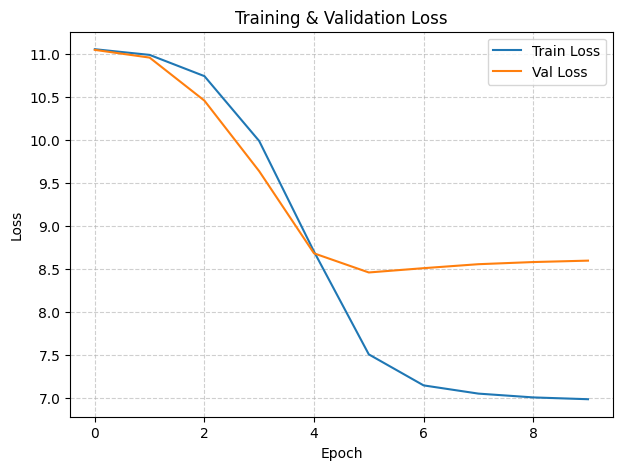

In [29]:
# Plot train/val loss
plot_history(history)

### Inference Example

In [30]:
# --- Load best checkpoint ---
checkpoint = torch.load("/kaggle/working/checkpoint.pt", map_location=device)
encoder.load_state_dict(checkpoint["encoder_state_dict"])
decoder.load_state_dict(checkpoint["decoder_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
encoder.to(device)
decoder.to(device)
print("Done.")

Done.


In [31]:
# Lấy 1 sample từ test_loader
sample = next(iter(test_loader))
input_ids = sample["input_ids"].to(device)
attention_mask = sample["attention_mask"].to(device)
labels = sample["labels"].to(device)

# Encode
encoder.eval()
decoder.eval()

sample_batch = next(iter(test_loader))
input_ids = sample_batch["input_ids"].to(device)
attention_mask = sample_batch["attention_mask"].to(device)

with torch.no_grad():
    encoder_outputs, encoder_hidden = encoder(input_ids, attention_mask)

    batch_size = input_ids.size(0)
    start_token_id = tokenizer.bos_token_id
    decoder_input = torch.full((batch_size,), start_token_id, dtype=torch.long, device=device)  # <sos>
    hidden = encoder_hidden
    decoded_ids = [[] for _ in range(batch_size)]

    max_len = 50
    for _ in range(max_len):
        logits, hidden, attn_weights = decoder(decoder_input, hidden, encoder_outputs, mask=attention_mask)
        next_tokens = logits.argmax(dim=1)
        for i in range(batch_size):
            decoded_ids[i].append(next_tokens[i].item())
        decoder_input = next_tokens


In [32]:
def generate_batch_summary(encoder, decoder, batch, tokenizer, start_token_id, end_token_id, max_len=50, device="cpu"):
    """
    Sinh summary cho cả batch từ DataLoader.
    
    batch: dict chứa 'input_ids' và 'attention_mask'
    tokenizer: để decode token IDs về text
    """
    encoder.eval()
    decoder.eval()
    
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    
    with torch.no_grad():
        encoder_outputs, encoder_hidden = encoder(input_ids, attention_mask)
        
        batch_size = input_ids.size(0)
        decoder_input = torch.full((batch_size,), start_token_id, dtype=torch.long, device=device)  # <sos>
        hidden = encoder_hidden
        decoded_ids = [[] for _ in range(batch_size)]
        finished = [False] * batch_size
        
        for _ in range(max_len):
            logits, hidden, attn_weights = decoder(decoder_input, hidden, encoder_outputs, mask=attention_mask)
            next_tokens = logits.argmax(dim=1)  # shape [batch_size]
            
            for i in range(batch_size):
                if not finished[i]:
                    decoded_ids[i].append(next_tokens[i].item())
                    if next_tokens[i].item() == end_token_id:
                        finished[i] = True
                        
            if all(finished):
                break
                
            decoder_input = next_tokens
    
    decoded_texts = [tokenizer.decode(ids, skip_special_tokens=True) for ids in decoded_ids]
    
    return decoded_texts


In [33]:
sample_batch = next(iter(test_loader))
summaries = generate_batch_summary(
    encoder, decoder, sample_batch,
    tokenizer,
    start_token_id=tokenizer.cls_token_id,
    end_token_id=tokenizer.sep_token_id,
    max_len=50,
    device=device
)

for i, summary in enumerate(summaries):
    print(f"Sample {i+1}: {summary}")


Sample 1: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Sample 2: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Sample 3: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Sample 4: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Sample 5: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Sample 6: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Sample 7: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
Sample 8: , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , , ,
